# Tool Change Intervals, Audited Against Measured Wear

A walkthrough of the tool wear calibration audit.

**Article:** https://kwantil.com/papers/tool-wear-calibration-audit/

---

### The question

Somewhere in a machine shop there is a number that decides when cutting inserts
get pulled. Twenty parts, or forty, or whatever the last argument about scrap
settled on. It came from experience, it is probably about right, and nobody can
say *how* right, because checking means stopping the machine and putting the tool
under a microscope.

In 1996 two researchers at Berkeley did exactly that, 167 times.

That is what makes this auditable: **a decision with the right answer written
down next to it.**

### How to read this notebook

Two things are run as scripts, because both are genuinely expensive: the feature
build over the raw signal files, and the calibration sweep (6 constructions x 4
feature sets x 25 seeds x 16 folds). **Everything else is computed here, in
front of you.** The conformal quantile, the two splits, the coverage arithmetic,
the leakage dial and the cluster bootstrap are a dozen lines each, and the
argument lives in those dozen lines rather than in a module you would have to go
and open.

Where a number from the article is reproduced, it is reproduced and then
`assert`ed against the published value. If the paper has rotted, this notebook
fails rather than agreeing with itself.

### The arc

| Section | What happens |
|---|---|
| 1 | Setup, and the fact that governs everything |
| 2 | An instrument that fails exactly where the decision is |
| 3 | The rule as a model, and how wrong it is |
| 4 | The interval a shop would quote, and what it actually covers |
| 5 | The trap: splitting by row instead of by insert, watched happening |
| 6 | Leakage as a dial, and an interval that respects the grouping |
| 7 | What honesty costs in tool life |
| 8 | What this does not support |

## How to run this

**Install.** Python 3.11 and five packages:

```bash
pip install numpy scipy pandas scikit-learn matplotlib
```

The first code cell prints the versions actually loaded next to the ones these
numbers were last reproduced under. A result here that disagrees with the
article is a version mismatch until proven otherwise, and `scikit-learn` is the
one to look at first: every interval below sits on its random forest.

**Data.** Nothing ships with this repository. One 14.7 MB download, extracted to
a 69 MB `mill.mat`:

```bash
cd analyses/tool-wear-calibration
curl -L -o milling.zip "https://phm-datasets.s3.amazonaws.com/NASA/3.+Milling.zip"
unzip -j milling.zip '*mill.mat' -d artifacts/raw/
```

Provenance, licence and the full rebuild: `DATA.md`.

**Two scripts do the expensive work.** Both are skipped when their output is
already on disk, so they cost nothing on a second run:

| Step | Command | Cold cost | Writes |
|---|---|---|---|
| Feature build over the raw signals | `python src/features.py` | a few minutes | `artifacts/interim/features.csv` |
| The calibration sweep | `python src/calibrate.py` | tens of minutes | `artifacts/interim/calibrated.csv` |

Run them at a shell first, or let sections 1 and 4 run them for you; it is the
same work either way.

**How long.** With both CSVs already built, the notebook itself takes about
**four minutes**, and all but one of those are two cells: the trap in section 5
(about a minute) and the leakage dial in section 6 (about three). Each is flagged in the markdown
directly above it. A cold run adds the two scripts, so it is dominated by
`calibrate.py` and lands in the tens of minutes.

**What works without the long step.** With `features.csv` alone -- minutes rather
than tens of them:

- Sections 1, 2 and 3 run in full.
- Section 5 builds the row-split trap from the data and section 6 builds the
  leakage dial, both from `features.csv` only. That is the transferable finding,
  and it does not need the sweep.
- Everything that reads `calibrated.csv` stops with the command that builds it:
  section 4, the two cross-checks in section 5, the coverage-interval table in
  section 6, and sections 7 and 8.

**When something is missing**, a cell stops with the path it wanted and the
command that produces it, not a traceback. If you run the cells out of order,
the same thing happens for whichever earlier cell you skipped.

## 1. Setup

No data ships with this repository. Download the NASA Milling Data Set and place
`mill.mat` at `artifacts/raw/mill.mat`; see `DATA.md`, or the two commands in
"How to run this" above.

The first code cell prints the environment. The next sets up paths, colours,
and the two helpers -- `need()` and `need_run()` -- that make a missing file or a skipped
cell stop with an instruction rather than a traceback.

In [1]:
# --- environment ----------------------------------------------------------
# The first code cell in the notebook, deliberately: every number below is
# asserted
# against the published article, and the cheapest explanation for a number
# that disagrees is a different package version.
import importlib
import platform
import sys

# What each package is here for, and the version the asserts below last passed
# under. scikit-learn is the sensitive one -- the random forest is its
# implementation, so a different minor version can move a third decimal and trip
# an assert that is otherwise perfectly healthy.
PACKAGES = [
    ("numpy", "2.2.6", "arrays, the RNG, the quantiles"),
    ("scipy", "1.17.1", "reads the MATLAB signal file, in src/features.py"),
    ("pandas", "2.2.3", "every table below"),
    ("matplotlib", "3.10.1", "the figures"),
    ("sklearn", "1.8.0", "the random forest behind every interval (pip: scikit-learn)"),
]
VERIFIED_PYTHON = "3.11.9"

print(f"python       {platform.python_version():<10}  verified {VERIFIED_PYTHON}")
print(f"platform     {platform.platform()}")
print()

missing, drifted = [], []
for name, verified, why in PACKAGES:
    try:
        module = importlib.import_module(name)
    except ImportError:
        missing.append(name)
        print(f"{name:<12} {'MISSING':<10}  {why}")
        continue
    version = getattr(module, "__version__", "unknown")
    if version != verified:
        drifted.append(name)
    mark = "  <-- differs" if version != verified else ""
    print(f"{name:<12} {version:<10}  verified {verified}{mark}   {why}")

if missing:
    pip_names = " ".join("scikit-learn" if m == "sklearn" else m for m in missing)
    raise SystemExit(
        f"Missing package(s): {', '.join(missing)}\n"
        f"  To install:\n"
        f"    pip install {pip_names}\n"
        f"  Full guide: DATA.md"
    )

print()
if drifted:
    print("Differs from the verified run:", ", ".join(drifted))
    print("Nothing is wrong yet. But if an assert below fails by a small margin,")
    print("this is the first thing to check and usually the whole explanation.")
else:
    print("Exactly the environment these numbers were last reproduced in.")

python       3.11.9      verified 3.11.9
platform     Windows-10-10.0.19045-SP0

numpy        2.2.6       verified 2.2.6   arrays, the RNG, the quantiles
scipy        1.17.1      verified 1.17.1   reads the MATLAB signal file, in src/features.py
pandas       2.2.3       verified 2.2.3   every table below
matplotlib   3.10.1      verified 3.10.1   the figures
sklearn      1.8.0       verified 1.8.0   the random forest behind every interval (pip: scikit-learn)

Exactly the environment these numbers were last reproduced in.


In [2]:
from pathlib import Path
import subprocess
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT / "src"))

pd.set_option("display.width", 130)
pd.set_option("display.max_columns", 30)
plt.rcParams.update({
    "figure.figsize": (9, 4.2), "figure.dpi": 110,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "font.size": 10,
})
INK, CLAY, MADDER, GOLD, SLATE = "#1a1815", "#8a4b23", "#8f2620", "#937212", "#2f4d78"

# Everything this notebook reads, and the exact command that builds each one.
# Quoted verbatim in every failure message, so a stuck reader never has to go
# and look one up.
RAW_MAT = "artifacts/raw/mill.mat"
FEATURES_REL = "artifacts/interim/features.csv"
CALIBRATED_REL = "artifacts/interim/calibrated.csv"
CURVE_REL = "artifacts/interim/decision_curve.csv"
FEATURES, CALIBRATED, CURVE = (ROOT / rel for rel in
                               (FEATURES_REL, CALIBRATED_REL, CURVE_REL))

HOW_RAW = ('curl -L -o milling.zip "https://phm-datasets.s3.amazonaws.com/NASA/3.+Milling.zip"\n'
           "    unzip -j milling.zip '*mill.mat' -d artifacts/raw/")
HOW_FEATURES = "python src/features.py       # a few minutes"
HOW_CALIBRATE = "python src/calibrate.py      # tens of minutes"
HOW_DECISION = "python src/decision.py       # seconds"


def need(rel: str, how: str) -> Path:
    """A file this cell reads. Fail with instructions rather than a bare traceback."""
    p = ROOT / rel
    if not p.exists():
        raise SystemExit(
            f"Missing {rel}\n"
            f"  This repository ships no data. To build it, from {ROOT}:\n"
            f"    {how}\n"
            f"  Full guide: DATA.md"
        )
    return p


def need_run(name: str, where: str) -> None:
    """A name an earlier cell defines. The same idea, for a notebook run out of order."""
    if name not in globals():
        raise SystemExit(
            f"`{name}` does not exist yet.\n"
            f"  Run {where} first; this notebook is meant to run top to bottom.\n"
            f"  Full guide: DATA.md"
        )


def run_script(script: str, cost: str) -> None:
    """Run one of the pipeline scripts, reporting a failure as an instruction."""
    print(f"running {script} -- {cost}. Its output follows.", flush=True)
    if subprocess.run([sys.executable, script], cwd=ROOT).returncode != 0:
        raise SystemExit(
            f"{script} failed.\n"
            f"  Run it at a shell to see the whole error:\n"
            f"    cd {ROOT}\n"
            f"    python {script}\n"
            f"  Full guide: DATA.md"
        )


print("analysis root:", ROOT.name)

analysis root: tool-wear-calibration


In [3]:
# What is on disk, and what each file gates. The 69 MB raw record is needed only
# to build features.csv, so once that exists the download can be deleted.
for rel, gates in [
    (RAW_MAT, "only needed in order to build features.csv"),
    (FEATURES_REL, "sections 1, 2, 3, and the constructions in 5 and 6"),
    (CALIBRATED_REL, "section 4, the cross-checks in 5 and 6, sections 7 and 8"),
    (CURVE_REL, "one optional cross-check in section 7"),
]:
    state = "present" if (ROOT / rel).exists() else "MISSING"
    print(f"  {state:>7}  {rel:<38}  {gates}")
print()

if not FEATURES.exists():
    need(RAW_MAT, HOW_RAW)      # only the feature build touches the raw signal file

# The shipped modules, imported as libraries rather than run as scripts. Every
# construction below is rebuilt by hand and then checked against these.
from calibrate import ALPHA, CAL_CASES, CONSTR, META, WEAR_LIMIT, conformal_q, rf
from decision import first_cut_where, outcomes
from ablation import sweep as ablation_sweep, wilson

print(f"nominal miscoverage alpha = {ALPHA}   calibration inserts = {CAL_CASES}"
      f"   wear limit = {WEAR_LIMIT} mm")
print("model features (this is the whole of the folklore rule):", META)
print("constructions:", CONSTR)

  present  artifacts/raw/mill.mat                  only needed in order to build features.csv
  present  artifacts/interim/features.csv          sections 1, 2, 3, and the constructions in 5 and 6
  present  artifacts/interim/calibrated.csv        section 4, the cross-checks in 5 and 6, sections 7 and 8
  present  artifacts/interim/decision_curve.csv    one optional cross-check in section 7

nominal miscoverage alpha = 0.1   calibration inserts = 4   wear limit = 0.6 mm
model features (this is the whole of the folklore rule): ['DOC', 'feed', 'material', 'cut_index']
constructions: ['G', 'G-cal', 'C-row', 'C-grp', 'C-norm', 'C-mond']


### The fact that governs everything

A Matsuura MC-510V machining centre. 70 mm face mill, 6 coated carbide inserts,
constant 200 m/min. Every combination of 2 materials, 2 depths of cut and 2
feeds, each run twice with a fresh set.

**16 inserts, 167 cuts, 146 with flank wear measured under a microscope.**

Now the part that decides every method below:

> Nine to twenty successive cuts share **one cutting edge** and one accumulated
> wear history. 146 cuts are nowhere near 146 independent observations.

The unit is the insert, not the cut. Every model here is fitted on some inserts
and tested on inserts it has never seen. Section 5 forgets that on purpose and
watches the result look fine.

The feature build is the first of this notebook's two scripts: it walks the raw
signal records, windows every cut and flags clipped channels.

> **Runtime.** `features.py` walks all 167 raw signal records: **a few minutes on
> a cold run**. It is skipped whenever `artifacts/interim/features.csv` already
> exists -- delete that file to force a rebuild. Reading the finished CSV is
> instant, which is the usual case.

In [4]:
if FEATURES.exists():
    print(f"using existing {FEATURES.name}; delete it to force a rebuild")
else:
    need(RAW_MAT, HOW_RAW)      # the feature build is the only step that reads it
    run_script("src/features.py", "a few minutes over the raw signal records")

raw = pd.read_csv(need(FEATURES_REL, HOW_FEATURES))
df = raw[raw["VB"].notna()].copy()      # the labelled cuts; everything below uses these
cuts_per_insert = df.groupby("case").size()

print(f"features.csv    : {raw.shape[0]} recorded cuts x {raw.shape[1]} columns")
print(f"labelled subset : {len(df)} cuts across {df['case'].nunique()} inserts")
print(f"cuts per insert : min {cuts_per_insert.min()}, median "
      f"{cuts_per_insert.median():.0f}, max {cuts_per_insert.max()}")
print(f"flank wear VB   : {df['VB'].min():.2f} to {df['VB'].max():.2f} mm")
print(f"inserts reaching the {WEAR_LIMIT} mm change point: "
      f"{int((df.groupby('case')['VB'].max() >= WEAR_LIMIT).sum())} of {df['case'].nunique()}")

assert len(raw) == 167, "article: 167 recorded cuts"
assert len(df) == 146, "article: 146 cuts carry a measured wear value"
assert df["case"].nunique() == 16, "article: 16 inserts"

df[["case", "run", "cut_index", "material", "DOC", "feed", "VB",
    "smcDC_clip_frac", "flag_corrupt"]].head(3)

using existing features.csv; delete it to force a rebuild
features.csv    : 167 recorded cuts x 71 columns
labelled subset : 146 cuts across 16 inserts
cuts per insert : min 1, median 8, max 20
flank wear VB   : 0.00 to 1.53 mm
inserts reaching the 0.6 mm change point: 10 of 16


,case,run,cut_index,material,DOC,feed,VB,smcDC_clip_frac,flag_corrupt
0,1.0,1.0,1,1.0,1.5,0.5,0.00,0.0,0
3,1.0,4.0,4,1.0,1.5,0.5,0.11,0.0,0
5,1.0,6.0,6,1.0,1.5,0.5,0.20,0.0,0


## 2. The instrument fails where the decision is

Before any modelling, a question about the data itself: are the sensors usable
across the whole range the decision covers?

The direct spindle-current channel is the one that most directly watches cutting
load. It is also amplified into a converter with a hard ceiling, and
`features.py` records what fraction of each cut's samples sat against that
ceiling. So the question is answerable in three lines: **does the channel clip
more on a worn tool than on a fresh one?**

In [5]:
need_run("raw", "the features.csv cell in section 1")

clip = raw["smcDC_clip_frac"]
heavy = raw[clip > 0.5]                 # more than half the cut against the ceiling
rest = raw[clip <= 0.5]

n_any, n_heavy = int((clip > 0).sum()), len(heavy)
vb_heavy, vb_rest = heavy["VB"].median(), rest["VB"].median()

print(f"runs with any clipping on smcDC : {n_any} of {len(raw)}")
print(f"runs more than half clipped     : {n_heavy}")
print(f"median flank wear, heavily clipped runs : {vb_heavy:.3f} mm")
print(f"median flank wear, all the rest         : {vb_rest:.3f} mm")
print(f"runs flagged DAQ-corrupt (kept and flagged, not dropped): "
      f"{int(raw['flag_corrupt'].sum())}")

assert n_any == 44, "article: smcDC clips in 44 of 167 runs"
assert n_heavy == 35, "article: 35 runs more than half clipped"
assert abs(vb_heavy - 0.500) < 0.005 and abs(vb_rest - 0.230) < 0.005, \
    "article: median VB 0.500 mm in heavily clipped runs against 0.230 mm in the rest"

print("\nThe load channel goes blind on a worn tool, which is the regime the change")
print("decision lives in. Any feature built on smcDC inherits that blindness.")

runs with any clipping on smcDC : 44 of 167
runs more than half clipped     : 35
median flank wear, heavily clipped runs : 0.500 mm
median flank wear, all the rest         : 0.230 mm
runs flagged DAQ-corrupt (kept and flagged, not dropped): 1

The load channel goes blind on a worn tool, which is the regime the change
decision lives in. Any feature built on smcDC inherits that blindness.


## 3. The rule as a model

A fixed change interval is a prediction: *after N cuts under these conditions,
wear will be acceptable.* That is a model, and it can be scored like one.

So fit it here. Four inputs, which is all the folklore rule has: cut number,
depth of cut, feed, material. Then hold out one whole insert at a time and
measure the error on cuts from an edge the model has never seen. Sixteen fits,
a few seconds. The fitted models are kept, because sections 5 and 6 vary only
the *calibration* split and refitting the point model each time would confound
the thing being varied with model noise.

The relevant comparison is against the change point itself, typically 0.60 mm of
flank wear for coated carbide.

In [6]:
need_run("df", "the features.csv cell in section 1")

def loio_predictions(frame: pd.DataFrame,
                     feats: list[str]) -> tuple[pd.DataFrame, dict[float, object]]:
    """Leave-one-insert-out predictions, keeping the fitted fold models.

    Uses calibrate.rf so that the model here is the shipped model, not a
    lookalike; the cross-check in section 5 depends on that being true.
    """
    preds, models = [], {}
    for held in np.sort(frame["case"].unique()):
        te, tr = frame[frame["case"] == held], frame[frame["case"] != held]
        models[held] = rf(random_state=0).fit(tr[feats], tr["VB"])
        out = te[["case", "cut_index", "VB"]].copy()
        out["pred"] = models[held].predict(te[feats])
        preds.append(out)
    p = pd.concat(preds, ignore_index=True)
    p["abs_err"] = (p["VB"] - p["pred"]).abs()
    return p, models


loio, FOLD_MODELS = loio_predictions(df, META)
rmse = float(np.sqrt((loio["abs_err"] ** 2).mean()))

print(f"{len(loio)} held-out predictions from {len(FOLD_MODELS)} folds")
print(f"leave-one-insert-out RMSE : {rmse:.4f} mm")
print(f"as a fraction of the {WEAR_LIMIT} mm change point : {rmse / WEAR_LIMIT:.2f}")
print(f"median absolute error     : {loio['abs_err'].median():.4f} mm")

assert abs(rmse - 0.165) < 0.005, f"article: LOIO RMSE 0.165 mm, got {rmse:.4f}"

loio.head(3)

146 held-out predictions from 16 folds
leave-one-insert-out RMSE : 0.1649 mm
as a fraction of the 0.6 mm change point : 0.27
median absolute error     : 0.0780 mm


,case,cut_index,VB,pred,abs_err
0,1.0,1,0.00,0.029987,0.029987
1,1.0,4,0.11,0.213595,0.103595
2,1.0,6,0.20,0.393253,0.193253


An error of a quarter of the change point is not a scandal. It is the honest
performance of the rule a shop is already running, and it is the number every
interval below has to be wide enough to cover.

The next plot decides section 4. It is not the error distribution; it is the
error **against the wear it is trying to measure**. A constant-width interval is
a horizontal line laid over this. The errors are not horizontal.

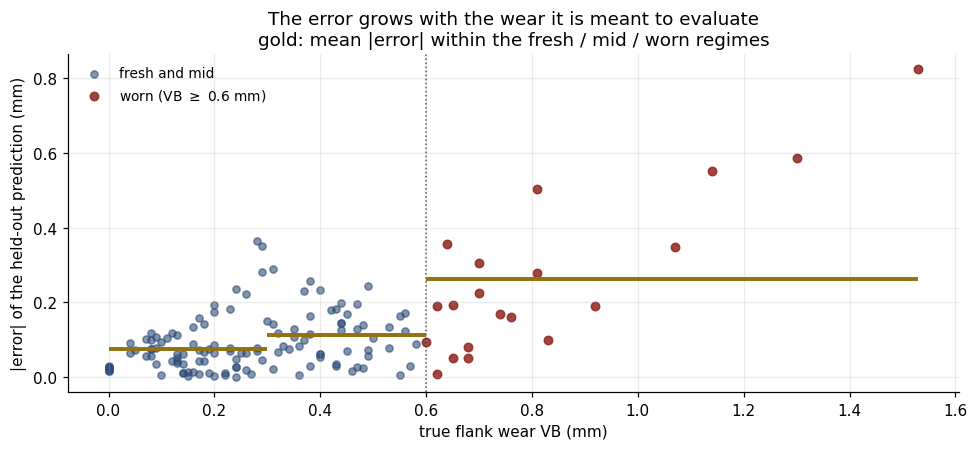

fresh  VB < 0.30   n= 76   mean |error| 0.075 mm
mid    0.30-0.60   n= 50   mean |error| 0.113 mm
worn   VB >= 0.60  n= 20   mean |error| 0.263 mm


In [7]:
need_run("loio", "the leave-one-insert-out cell just above")

fig, ax = plt.subplots()
worn_mask = loio["VB"] >= WEAR_LIMIT
ax.scatter(loio.loc[~worn_mask, "VB"], loio.loc[~worn_mask, "abs_err"],
           s=22, color=SLATE, alpha=0.6, label="fresh and mid")
ax.scatter(loio.loc[worn_mask, "VB"], loio.loc[worn_mask, "abs_err"],
           s=30, color=MADDER, alpha=0.85, label=f"worn (VB $\\geq$ {WEAR_LIMIT} mm)")
ax.axvline(WEAR_LIMIT, color=INK, lw=1.0, ls=":", alpha=0.7)

for lo, hi in [(0.0, 0.30), (0.30, WEAR_LIMIT), (WEAR_LIMIT, 99.0)]:
    band = loio["VB"].between(lo, hi, inclusive="left")
    ax.hlines(loio.loc[band, "abs_err"].mean(), lo, min(hi, loio["VB"].max()),
              color=GOLD, lw=2.6, zorder=5)

ax.set_xlabel("true flank wear VB (mm)")
ax.set_ylabel("|error| of the held-out prediction (mm)")
ax.set_title("The error grows with the wear it is meant to evaluate\n"
             "gold: mean |error| within the fresh / mid / worn regimes")
ax.legend(frameon=False, fontsize=9)
plt.tight_layout(); plt.show()

for lab, band in [("fresh  VB < 0.30 ", loio["VB"] < 0.30),
                  ("mid    0.30-0.60 ", loio["VB"].between(0.30, WEAR_LIMIT, inclusive="left")),
                  ("worn   VB >= 0.60", loio["VB"] >= WEAR_LIMIT)]:
    print(f"{lab}  n={int(band.sum()):>3}   mean |error| "
          f"{loio.loc[band, 'abs_err'].mean():.3f} mm")

That is section 4 in advance. Any interval quoted as a single width will cover
generously on a fresh tool and run out exactly where the wear limit is.

## 4. The interval, and what it covers

A shop quoting a range around a prediction almost always does this: take the
standard deviation of past errors, multiply by 1.645, quote plus-or-minus. That
is a 90% interval **if** the errors are normal and **if** the standard deviation
was computed on data the model has not seen.

$$\hat{y} \pm 1.645\,\hat{\sigma}$$

Both conditions usually fail. The audit separates them, because they are not the
same mistake and they do not cost the same:

- **G** takes $\hat\sigma$ from the data the model was fitted on
- **G-cal** takes $\hat\sigma$ from held-out calibration inserts, and keeps the
  normal shape
- **C-grp** uses the same held-out inserts but reads the width off the empirical
  error distribution, assuming nothing about shape

G to G-cal is the in-sample mistake, priced. G-cal to nominal is the
normal-shape mistake, priced. The sweep below fits all six constructions across
4 feature sets, 25 seeds and 16 leave-one-insert-out folds. It is the second and
last script in this notebook.

> **Runtime.** This is the long one: **tens of minutes cold**, and the only thing
> in the notebook that takes that long. It is skipped whenever
> `artifacts/interim/calibrated.csv` already exists -- delete that file to force
> a re-run. Reading the finished CSV takes under a second.

In [8]:
if CALIBRATED.exists():
    print(f"using existing {CALIBRATED.name}; delete it to force a re-run")
else:
    print("6 constructions x 4 feature sets x 25 seeds x 16 folds.")
    run_script("src/calibrate.py", "the long step, tens of minutes")

res = pd.read_csv(need(CALIBRATED_REL, HOW_CALIBRATE))
meta = res[res["variant"] == "meta"]        # the fixed-rule model, 4 features

print(f"\n{len(res):,} calibrated predictions "
      f"({res['variant'].nunique()} feature sets x {res['seed'].nunique()} seeds "
      f"x {res['case'].nunique()} folds)")
print("one row per held-out cut, with a half-width q_* per construction;")
print("cov_* and wid_* are derived: |VB - pred| <= q, and 2q.")
meta[["case", "cut_index", "VB", "pred", "q_G", "q_G-cal", "q_C-row",
      "q_C-grp", "cov_G", "cov_C-grp"]].head(3)

using existing calibrated.csv; delete it to force a re-run

14,600 calibrated predictions (4 feature sets x 25 seeds x 16 folds)
one row per held-out cut, with a half-width q_* per construction;
cov_* and wid_* are derived: |VB - pred| <= q, and 2q.


,case,cut_index,VB,pred,q_G,q_G-cal,q_C-row,q_C-grp,cov_G,cov_C-grp
0,1.0,1,0.00,0.029987,0.111494,0.32948,0.192461,0.377732,1,1
1,1.0,4,0.11,0.213595,0.111494,0.32948,0.192461,0.377732,1,1
2,1.0,6,0.20,0.393253,0.111494,0.32948,0.192461,0.377732,0,1


### Coverage, by hand

The claim is arithmetic, so check it arithmetically rather than reading a
summary the script printed. A cut is covered when the absolute error falls
inside the half-width, so coverage is a mean of indicators. The only subtlety is
the averaging order: **average within a seed first**, then across seeds, because
the 25 seeds are 25 independent draws of the calibration split.

In [9]:
need_run("meta", "the calibrated.csv cell at the top of section 4")

def coverage_table(frame: pd.DataFrame, constructions: list[str]) -> pd.DataFrame:
    """Coverage and width per construction, averaged within seed then across seeds.

    Pooling rows across seeds instead would let the noisier draws pull the mean,
    and the spread across draws is itself a published quantity.
    """
    rows = []
    for c in constructions:
        per_seed = frame.groupby("seed")[f"cov_{c}"].mean()
        width = frame.groupby("seed")[f"wid_{c}"].median()
        rows.append({
            "construction": c,
            "coverage %": 100 * per_seed.mean(),
            "5th pct": 100 * per_seed.quantile(0.05),
            "95th pct": 100 * per_seed.quantile(0.95),
            "median width mm": width.mean(),
            "width / limit": width.mean() / WEAR_LIMIT,
        })
    return pd.DataFrame(rows).set_index("construction")


# The indicator, recomputed from scratch and checked against the shipped column.
by_hand = (np.abs(meta["VB"] - meta["pred"]) <= meta["q_G"]).to_numpy()
assert (by_hand == meta["cov_G"].to_numpy().astype(bool)).all(), \
    "cov_G in the artifact is not |VB - pred| <= q_G"

cov = coverage_table(meta, CONSTR)
print(f"nominal coverage: {100 * (1 - ALPHA):.0f}%\n")
cov.round(2)

nominal coverage: 90%



,coverage %,5th pct,95th pct,median width mm,width / limit
construction,,,,,
G,68.49,68.49,68.49,0.26,0.43
G-cal,84.36,78.36,89.04,0.47,0.78
C-row,89.84,84.93,94.93,0.54,0.89
C-grp,92.19,87.12,95.21,0.66,1.10
C-norm,92.93,88.49,96.99,0.71,1.19
C-mond,91.26,86.99,95.21,0.56,0.94


In [10]:
need_run("cov", "the coverage table cell just above")

g, g_cal, c_grp = (float(cov.loc[k, "coverage %"]) for k in ("G", "G-cal", "C-grp"))
nominal = 100 * (1 - ALPHA)

print(f"G      Gaussian, in-sample sigma      {g:5.1f}%   shortfall {nominal - g:5.1f} pts")
print(f"G-cal  Gaussian, held-out sigma       {g_cal:5.1f}%   shortfall {nominal - g_cal:5.1f} pts")
print(f"C-grp  conformal, held-out by insert  {c_grp:5.1f}%")
print()
print(f"  cost of the IN-SAMPLE mistake    (G  -> G-cal) : {g_cal - g:5.1f} points")
print(f"  cost of the NORMAL-SHAPE mistake (G-cal -> 90) : {nominal - g_cal:5.1f} points")
print(f"  total shortfall against nominal                : {nominal - g:5.1f} points")

assert abs(g - 68.5) < 0.5, f"article: 68.5% for the Gaussian habit, got {g:.1f}"
assert abs(g_cal - 84.4) < 0.5, f"article: 84.4% once sigma is held out, got {g_cal:.1f}"
assert abs((g_cal - g) - 16) < 1.5, "article: roughly 16 points from the in-sample sigma"
assert abs((nominal - g_cal) - 6) < 1.5, "article: only about 6 points from the normal shape"

print("\nThe assumption everybody argues about is the smaller half.")

G      Gaussian, in-sample sigma       68.5%   shortfall  21.5 pts
G-cal  Gaussian, held-out sigma        84.4%   shortfall   5.6 pts
C-grp  conformal, held-out by insert   92.2%

  cost of the IN-SAMPLE mistake    (G  -> G-cal) :  15.9 points
  cost of the NORMAL-SHAPE mistake (G-cal -> 90) :   5.6 points
  total shortfall against nominal                :  21.5 points

The assumption everybody argues about is the smaller half.


### And it fails conditionally, where the decision is

A marginal number averages a well-described fresh tool against a badly described
worn one. Split it by regime and the interval a shop would quote when the
question is *can this insert do one more part* is the one that fails.

In [11]:
need_run("cov", "the coverage table cell in section 4")

worn = meta[meta["VB"] >= WEAR_LIMIT]
worn_col = f"worn VB>={WEAR_LIMIT}"

regimes = pd.DataFrame({
    "all cuts": cov["coverage %"],
    "fresh VB<0.30": coverage_table(meta[meta["VB"] < 0.30], CONSTR)["coverage %"],
    "mid 0.30-0.60": coverage_table(
        meta[meta["VB"].between(0.30, WEAR_LIMIT, inclusive="left")], CONSTR)["coverage %"],
    worn_col: coverage_table(worn, CONSTR)["coverage %"],
})
print(f"worn regime: {int(worn.groupby('seed').size().mean())} cuts per seed out of "
      f"{int(meta.groupby('seed').size().mean())}\n")
print(regimes.round(1).to_string())

w_gcal = float(regimes.loc["G-cal", worn_col])
w_grp = float(regimes.loc["C-grp", worn_col])
assert abs(w_gcal - 55.0) < 0.5, f"article: G-cal covers 55.0% when worn, got {w_gcal:.1f}"
assert abs(w_grp - 68.0) < 0.5, f"article: conformal covers 68.0% when worn, got {w_grp:.1f}"

print(f"\nWorn: the like-for-like Gaussian covers {w_gcal:.1f}%. The distribution-free")
print(f"construction, on the SAME held-out calibration inserts, covers {w_grp:.1f}%.")
print(f"Dropping the normal shape buys {w_grp - w_gcal:.0f} points exactly where they are")
print(f"needed, and still leaves {90 - w_grp:.0f} on the table. 16 inserts do not contain")
print("enough worn cuts to calibrate the worn regime.")

worn regime: 20 cuts per seed out of 146

              all cuts  fresh VB<0.30  mid 0.30-0.60  worn VB>=0.6
construction                                                      
G                 68.5           85.5           58.0          30.0
G-cal             84.4           92.3           84.1          55.0
C-row             89.8           95.1           93.4          60.8
C-grp             92.2           96.4           95.5          68.0
C-norm            92.9           93.8           97.3          78.6
C-mond            91.3           95.9           94.7          64.8

Worn: the like-for-like Gaussian covers 55.0%. The distribution-free
construction, on the SAME held-out calibration inserts, covers 68.0%.
Dropping the normal shape buys 13 points exactly where they are
needed, and still leaves 22 on the table. 16 inserts do not contain
enough worn cuts to calibrate the worn regime.


## 5. The trap

This is the most transferable result in the analysis, and it generalises far
beyond machining. It is also the one thing in this notebook that has to be
watched rather than reported, so it is built here from the data.

Split conformal prediction promises 90% coverage if the calibration errors are
exchangeable with the error on the next observation. Hold out random **rows**
instead of whole **inserts** and cuts from the same cutting edge sit on both
sides of the split. The calibration errors are then errors on cuts the model has
half-seen, and the promise no longer applies to the question being asked.

Everything else is held fixed: same data, same model, same calibration set
*size*, same nominal level. Only the split changes.

In [12]:
def conformal_quantile(scores: np.ndarray, alpha: float = ALPHA) -> float:
    """Finite-sample conformal quantile: ceil((n+1)(1-alpha))/n, taken from above.

    Written out rather than imported because the (n+1) and the "from above" are
    the entire finite-sample guarantee, and a reader who cannot see them has to
    take the coverage claim on trust.
    """
    n = len(scores)
    if n == 0:
        return np.inf
    level = min(1.0, np.ceil((n + 1) * (1 - alpha)) / n)
    return float(np.quantile(scores, level, method="higher"))


check_rng = np.random.default_rng(0)
for n in (5, 17, 35, 130):
    s = np.abs(check_rng.normal(size=n))
    lvl = min(1.0, np.ceil((n + 1) * (1 - ALPHA)) / n)
    print(f"n={n:>4} calibration errors -> take the {100 * lvl:.1f}th percentile "
          f"to promise {100 * (1 - ALPHA):.0f}%")
    assert abs(conformal_quantile(s) - conformal_q(s)) < 1e-15, \
        f"diverges from the shipped calibrate.conformal_q at n={n}"

print("\nidentical to calibrate.conformal_q. Note the inflation: with 35 calibration")
print("errors a 90% promise costs the 94th percentile, and that gap is the price of")
print("finite samples rather than a fudge factor.")

n=   5 calibration errors -> take the 100.0th percentile to promise 90%
n=  17 calibration errors -> take the 100.0th percentile to promise 90%
n=  35 calibration errors -> take the 94.3th percentile to promise 90%
n= 130 calibration errors -> take the 90.8th percentile to promise 90%

identical to calibrate.conformal_q. Note the inflation: with 35 calibration
errors a 90% promise costs the 94th percentile, and that gap is the price of
finite samples rather than a fudge factor.


> **Runtime: about a minute, every time.** Nothing here is cached. The cell
> refits the forest twice per fold -- 6 calibration draws x 16 folds x 2 splits,
> close to 200 fits -- because the whole point is to watch the two splits happen
> on identical data. Set `TRAP_SEEDS = 2` for a quick pass; the published sweep
> uses 25 draws and is already sitting in `calibrated.csv`.

In [13]:
need_run("FOLD_MODELS", "the leave-one-insert-out cell in section 3")

def trap_fold(tr: pd.DataFrame, te: pd.DataFrame, feats: list[str],
              rng: np.random.Generator, point_model: object) -> dict[str, object]:
    """One held-out insert, calibrated two ways on identical data.

    The generator is drawn from in exactly the order calibrate.one_fold uses
    (insert choice, then row permutation), so the quantiles produced here are the
    shipped ones rather than merely similar to them. That is what makes the
    cross-check in the next cell meaningful.
    """
    # --- split by INSERT: four whole cutting edges kept out of the fit ----------
    others = np.sort(tr["case"].unique())
    cal_cases = rng.choice(others, size=min(CAL_CASES, len(others) - 1), replace=False)
    fit_g, cal_g = tr[~tr["case"].isin(cal_cases)], tr[tr["case"].isin(cal_cases)]
    m_g = rf(random_state=0).fit(fit_g[feats], fit_g["VB"])
    res_grp = np.abs(cal_g["VB"].to_numpy() - m_g.predict(cal_g[feats]))

    # --- split by ROW: same calibration size, rows drawn at random --------------
    order = rng.permutation(len(tr))
    cal_r, fit_r = tr.iloc[order[:len(cal_g)]], tr.iloc[order[len(cal_g):]]
    m_r = rf(random_state=0).fit(fit_r[feats], fit_r["VB"])
    res_row = np.abs(cal_r["VB"].to_numpy() - m_r.predict(cal_r[feats]))

    return {
        "q_grp": conformal_quantile(res_grp), "q_row": conformal_quantile(res_row),
        "res_grp": res_grp, "res_row": res_row, "n_cal": len(cal_g),
        "err": np.abs(te["VB"].to_numpy() - point_model.predict(te[feats])),
        "shared_edges": int(cal_r["case"].isin(fit_r["case"]).sum()),
    }


TRAP_SEEDS = 6          # the artifact carries all 25; six is enough to watch it happen
rows, pools = [], {}

for seed in range(TRAP_SEEDS):
    rng = np.random.default_rng(1000 + seed)        # the seeding calibrate.py uses
    for held in np.sort(df["case"].unique()):
        te, tr = df[df["case"] == held], df[df["case"] != held]
        if te.empty or len(tr) < 20:
            continue
        f = trap_fold(tr, te, META, rng, FOLD_MODELS[held])
        if seed == 0:
            pools[held] = f          # keep the first draw's pools for the plot below
        for vb, e in zip(te["VB"].to_numpy(), f["err"]):
            rows.append({"seed": seed, "case": held, "VB": vb, "abs_err": e,
                         "q_grp": f["q_grp"], "q_row": f["q_row"],
                         "cov_grp": int(e <= f["q_grp"]), "cov_row": int(e <= f["q_row"])})

trap = pd.DataFrame(rows)
first = pools[min(pools)]
print(f"{len(trap)} held-out cuts x {TRAP_SEEDS} calibration draws")
print(f"calibration set size, either split : {first['n_cal']} cuts")
print("of the row split's calibration cuts, how many come from an edge that is")
print(f"also in the fitting set: {first['shared_edges']} of {first['n_cal']}\n")
trap.head(3)

876 held-out cuts x 6 calibration draws
calibration set size, either split : 45 cuts
of the row split's calibration cuts, how many come from an edge that is
also in the fitting set: 44 of 45



,seed,case,VB,abs_err,q_grp,q_row,cov_grp,cov_row
0,0,1.0,0.00,0.029987,0.377732,0.192461,1,1
1,0,1.0,0.11,0.103595,0.377732,0.192461,1,1
2,0,1.0,0.20,0.193253,0.377732,0.192461,1,0


In [14]:
need_run("trap", "the trap cell just above")

per_seed = trap.groupby("seed")[["cov_grp", "cov_row"]].mean() * 100
per_seed["width_grp"] = 2 * trap.groupby("seed")["q_grp"].median()
per_seed["width_row"] = 2 * trap.groupby("seed")["q_row"].median()
print(per_seed.round(2).to_string())
print(f"\nmean over these {TRAP_SEEDS} draws: "
      f"insert split {per_seed['cov_grp'].mean():.1f}%, row split {per_seed['cov_row'].mean():.1f}%")
print("Look at the spread down the column before reading the mean. A single draw of")
print("this experiment can land anywhere across several points, which is why the")
print("published sweep repeats it 25 times instead of reporting once.")

      cov_grp  cov_row  width_grp  width_row
seed                                        
0       94.52    84.93       0.76       0.52
1       95.21    89.73       0.79       0.57
2       91.78    95.21       0.72       0.93
3       85.62    88.36       0.57       0.50
4       89.73    87.67       0.60       0.48
5       90.41    90.41       0.72       0.54

mean over these 6 draws: insert split 91.2%, row split 89.4%
Look at the spread down the column before reading the mean. A single draw of
this experiment can land anywhere across several points, which is why the
published sweep repeats it 25 times instead of reporting once.


### Cross-check: is this the shipped construction, or a lookalike?

The reimplementation above is fifteen lines. That is only worth anything if it
is the same fifteen lines the pipeline runs, so compare the quantiles it
produced against the ones in `calibrated.csv`, fold by fold and draw by draw.

This is the cell that licenses everything else in this section.

In [15]:
need_run("meta", "the calibrated.csv cell at the top of section 4")

mine = trap.groupby(["seed", "case"])[["q_grp", "q_row"]].first()
shipped = (meta[meta["seed"] < TRAP_SEEDS]
           .groupby(["seed", "case"])[["q_C-grp", "q_C-row"]].first())

d_grp = float((mine["q_grp"] - shipped["q_C-grp"]).abs().max())
d_row = float((mine["q_row"] - shipped["q_C-row"]).abs().max())
print(f"compared {len(mine)} (draw, fold) pairs")
print(f"largest disagreement, insert split : {d_grp:.3e}")
print(f"largest disagreement, row split    : {d_row:.3e}")

assert d_grp < 1e-10 and d_row < 1e-10, \
    "the notebook's splits are not the shipped splits; the section below is void"

print("\nIdentical to floating point. The notebook is running the pipeline's")
print("construction, not an approximation of it.")

compared 96 (draw, fold) pairs
largest disagreement, insert split : 2.776e-16
largest disagreement, row split    : 3.608e-16

Identical to floating point. The notebook is running the pipeline's
construction, not an approximation of it.


### The mechanism, in one fold

Why does the leaky split come out narrower? Because the pool it takes its
quantile from is shorter in the tail. A calibration cut whose insert also sits
in the fitting set is not a fresh error; the forest has already learned that
edge's wear history from its neighbours.

Below: one fold, both calibration pools, both conformal quantiles, and the
errors that fold actually has to cover.

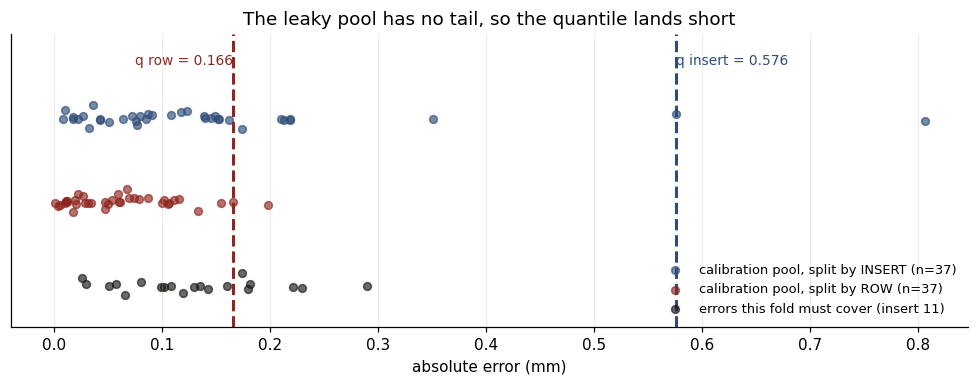

conformal quantile, insert split : 0.576 mm
conformal quantile, row split    : 0.166 mm
insert-split pool: 90th pct 0.218 mm, max 0.806 mm
row-split pool   : 90th pct 0.123 mm, max 0.198 mm

Over all 6 draws and 16 folds, of 876 held-out cuts:
  covered by the insert split, missed by the row split : 45
  the reverse                                          : 29
Those are cuts a shop would have been told were inside the interval.


In [16]:
need_run("pools", "the trap cell in section 5")

gaps = {case: pool["q_grp"] - pool["q_row"] for case, pool in pools.items()}
focus = max(gaps, key=gaps.get)          # the fold where the two splits disagree most
f = pools[focus]

fig, ax = plt.subplots(figsize=(9, 3.6))
jit = np.random.default_rng(3).normal(scale=0.045, size=200)
for y, vals, colour, lab in [
        (2.0, f["res_grp"], SLATE, f"calibration pool, split by INSERT (n={len(f['res_grp'])})"),
        (1.0, f["res_row"], MADDER, f"calibration pool, split by ROW (n={len(f['res_row'])})"),
        (0.0, f["err"], INK, f"errors this fold must cover (insert {focus:.0f})")]:
    ax.scatter(vals, y + jit[:len(vals)], s=26, color=colour, alpha=0.65, label=lab)

ax.axvline(f["q_grp"], color=SLATE, lw=2.0, ls="--")
ax.axvline(f["q_row"], color=MADDER, lw=2.0, ls="--")
ax.annotate(f"q insert = {f['q_grp']:.3f}", (f["q_grp"], 2.6), color=SLATE, fontsize=9,
            ha="left", va="bottom")
ax.annotate(f"q row = {f['q_row']:.3f}", (f["q_row"], 2.6), color=MADDER, fontsize=9,
            ha="right", va="bottom")
ax.set_yticks([]); ax.set_ylim(-0.5, 3.0)
ax.set_xlabel("absolute error (mm)")
ax.set_title("The leaky pool has no tail, so the quantile lands short")
ax.legend(frameon=False, fontsize=8.5, loc="lower right")
plt.tight_layout(); plt.show()

print(f"conformal quantile, insert split : {f['q_grp']:.3f} mm")
print(f"conformal quantile, row split    : {f['q_row']:.3f} mm")
print(f"insert-split pool: 90th pct {np.percentile(f['res_grp'], 90):.3f} mm, "
      f"max {f['res_grp'].max():.3f} mm")
print(f"row-split pool   : 90th pct {np.percentile(f['res_row'], 90):.3f} mm, "
      f"max {f['res_row'].max():.3f} mm")

only_grp = int(((trap["cov_grp"] == 1) & (trap["cov_row"] == 0)).sum())
only_row = int(((trap["cov_row"] == 1) & (trap["cov_grp"] == 0)).sum())
print()
print(f"Over all {TRAP_SEEDS} draws and {trap['case'].nunique()} folds, of "
      f"{len(trap)} held-out cuts:")
print(f"  covered by the insert split, missed by the row split : {only_grp}")
print(f"  the reverse                                          : {only_row}")
print("Those are cuts a shop would have been told were inside the interval.")

### What the published sweep says, over all 25 draws

The six draws above are enough to see the mechanism. The headline is the mean
over 25, which is what `calibrated.csv` holds.

In [17]:
need_run("cov", "the coverage table cell in section 4")

head = pd.DataFrame({
    "rows split at random (C-row)": [cov.loc["C-row", "coverage %"],
                                     cov.loc["C-row", "median width mm"],
                                     regimes.loc["C-row", worn_col]],
    "split by insert (C-grp)": [cov.loc["C-grp", "coverage %"],
                                cov.loc["C-grp", "median width mm"],
                                regimes.loc["C-grp", worn_col]],
}, index=["marginal coverage %", "median width mm", "coverage %, worn regime"])
print(head.round(3).to_string())

c_row = float(cov.loc["C-row", "coverage %"])
narrower = 100 * (1 - cov.loc["C-row", "median width mm"] / cov.loc["C-grp", "median width mm"])
print(f"\nmarginal coverage of the leaky construction : {c_row:.1f}% against a nominal 90%")
print(f"how much narrower it is than the honest one : {narrower:.0f}%")
print(f"worn-regime coverage, leaky vs honest       : "
      f"{regimes.loc['C-row', worn_col]:.1f}% vs {regimes.loc['C-grp', worn_col]:.1f}%")

assert abs(c_row - 89.8) < 0.5, f"article: 89.8% for the row split, got {c_row:.1f}"
assert abs(c_row - 90.0) < 1.0, "the article's point is that this passes a marginal check"
assert abs(narrower - 19) < 2, f"article: 19% too narrow, got {narrower:.0f}%"

print("\nLeakage does not show up as broken coverage. It shows up as an interval that")
print("is 19% sharper, passes the check everybody runs, and under-covers exactly")
print("where the decision is made. It fails by looking confident.")

                         rows split at random (C-row)  split by insert (C-grp)
marginal coverage %                            89.836                   92.192
median width mm                                 0.535                    0.661
coverage %, worn regime                        60.800                   68.000

marginal coverage of the leaky construction : 89.8% against a nominal 90%
how much narrower it is than the honest one : 19%
worn-regime coverage, leaky vs honest       : 60.8% vs 68.0%

Leakage does not show up as broken coverage. It shows up as an interval that
is 19% sharper, passes the check everybody runs, and under-covers exactly
where the decision is made. It fails by looking confident.


## 6. Leakage as a dial

Row split and insert split are the two ends of something continuous, and the
continuum is worth seeing because real leakage is rarely total. Take the same
four calibration inserts; then replace a fraction $f$ of their calibration cuts
with cuts drawn from anywhere in the training pool. At $f=0$ this is the insert
split. At $f=1$ it is the row split. In between, the calibration set is
partially contaminated in the way a real pipeline usually is.

The point model is held fixed throughout: only the calibration split moves.

> **Runtime: about three minutes, every time.** No caching here either: 6 draws x
> 16 folds x 5 leakage fractions is roughly 500 forest fits, which makes this the
> slowest cell in the notebook. Drop `LEAK_SEEDS` to 2, or shorten `FRACS`, for a
> quicker look at the same shape.

In [18]:
need_run("FOLD_MODELS", "the leave-one-insert-out cell in section 3")

def leak_fold(tr: pd.DataFrame, te: pd.DataFrame, own: np.ndarray, frac: float,
              feats: list[str], rng: np.random.Generator,
              point_model: object) -> dict[str, float]:
    """Calibrate on `own` inserts with a fraction `frac` of the cuts swapped for
    cuts from anywhere in the training pool, then score the held-out insert.

    Calibration size is held constant so that width changes come from leakage and
    not from a smaller pool, which would move the conformal quantile on its own.
    """
    k = int(round(frac * len(own)))
    leaked = rng.choice(tr.index.to_numpy(), size=k, replace=False)
    clean = np.setdiff1d(own, leaked)
    cal_idx = np.concatenate([leaked, rng.choice(clean, size=min(len(own) - k, len(clean)),
                                                 replace=False)])
    cal, fit = tr.loc[cal_idx], tr.drop(index=cal_idx)
    m = rf(random_state=0).fit(fit[feats], fit["VB"])
    q = conformal_quantile(np.abs(cal["VB"].to_numpy() - m.predict(cal[feats])))

    err = np.abs(te["VB"].to_numpy() - point_model.predict(te[feats]))
    hot = te["VB"].to_numpy() >= WEAR_LIMIT
    return {"q": q, "n": len(err), "covered": int((err <= q).sum()),
            "n_worn": int(hot.sum()), "covered_worn": int((err[hot] <= q).sum())}


FRACS = [0.0, 0.25, 0.5, 0.75, 1.0]
LEAK_SEEDS = 6
leak_rows = []
for seed in range(LEAK_SEEDS):
    rng = np.random.default_rng(2000 + seed)
    for held in np.sort(df["case"].unique()):
        te, tr = df[df["case"] == held], df[df["case"] != held]
        cal_cases = rng.choice(np.sort(tr["case"].unique()), size=CAL_CASES, replace=False)
        own = tr.index[tr["case"].isin(cal_cases)].to_numpy()
        for frac in FRACS:
            leak_rows.append({"seed": seed, "case": held, "frac": frac,
                              **leak_fold(tr, te, own, frac, META, rng, FOLD_MODELS[held])})

leak = pd.DataFrame(leak_rows)
by_frac = leak.groupby("frac")
dial = pd.DataFrame({
    "marginal coverage %": 100 * by_frac["covered"].sum() / by_frac["n"].sum(),
    "worn coverage %": 100 * by_frac["covered_worn"].sum() / by_frac["n_worn"].sum(),
    "median width mm": 2 * by_frac["q"].median(),
})
dial.index.name = "fraction of calibration cuts leaked"
print(dial.round(2).to_string())

                                     marginal coverage %  worn coverage %  median width mm
fraction of calibration cuts leaked                                                       
0.00                                               92.47            68.33             0.64
0.25                                               91.67            65.00             0.57
0.50                                               91.10            63.33             0.56
0.75                                               88.93            60.00             0.53
1.00                                               91.10            62.50             0.52


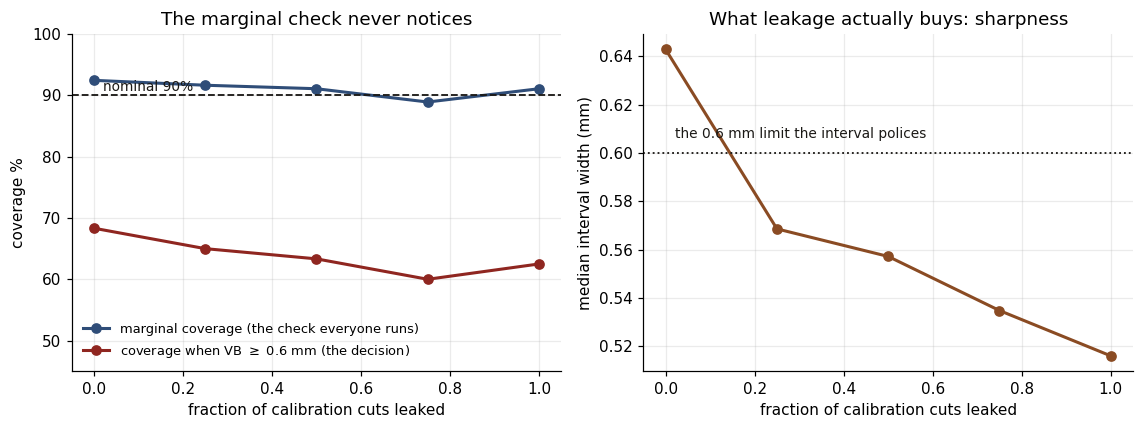

width from a clean split to a fully leaked one: 0.643 -> 0.516 mm (20% narrower)
marginal coverage across the whole dial: 88.9% to 92.5%

The left panel is the point. The blue line stays inside the range any
reviewer would accept, from a clean split all the way to a fully leaked one,
while the red line falls away underneath it.


In [19]:
need_run("dial", "the leakage-dial cell just above")

fig, (ax, ax2) = plt.subplots(1, 2, figsize=(10.5, 4.0))

ax.plot(dial.index, dial["marginal coverage %"], "o-", color=SLATE, lw=2,
        label="marginal coverage (the check everyone runs)")
ax.plot(dial.index, dial["worn coverage %"], "o-", color=MADDER, lw=2,
        label=f"coverage when VB $\\geq$ {WEAR_LIMIT} mm (the decision)")
ax.axhline(100 * (1 - ALPHA), color=INK, lw=1.2, ls="--")
ax.annotate("nominal 90%", (0.02, 100 * (1 - ALPHA) + 0.8), fontsize=9, color=INK)
ax.set_ylim(45, 100); ax.set_xlabel("fraction of calibration cuts leaked")
ax.set_ylabel("coverage %")
ax.set_title("The marginal check never notices")
ax.legend(frameon=False, fontsize=8.5, loc="lower left")

ax2.plot(dial.index, dial["median width mm"], "o-", color=CLAY, lw=2)
ax2.axhline(WEAR_LIMIT, color=INK, lw=1.2, ls=":")
ax2.annotate(f"the {WEAR_LIMIT} mm limit the interval polices", (0.02, WEAR_LIMIT + 0.006),
             fontsize=9, color=INK)
ax2.set_xlabel("fraction of calibration cuts leaked")
ax2.set_ylabel("median interval width (mm)")
ax2.set_title("What leakage actually buys: sharpness")
plt.tight_layout(); plt.show()

drop = 100 * (1 - dial["median width mm"].iloc[-1] / dial["median width mm"].iloc[0])
print(f"width from a clean split to a fully leaked one: "
      f"{dial['median width mm'].iloc[0]:.3f} -> {dial['median width mm'].iloc[-1]:.3f} mm "
      f"({drop:.0f}% narrower)")
print(f"marginal coverage across the whole dial: "
      f"{dial['marginal coverage %'].min():.1f}% to {dial['marginal coverage %'].max():.1f}%")
print("\nThe left panel is the point. The blue line stays inside the range any")
print("reviewer would accept, from a clean split all the way to a fully leaked one,")
print("while the red line falls away underneath it.")

### And the interval on the coverage number itself

One more grouping mistake, because it is the same mistake wearing a different
hat. A Wilson interval on 146 cuts treats them as 146 independent Bernoulli
draws. They are not: they are 16 inserts. The honest interval resamples
**inserts** with replacement, carrying each insert's whole block of cuts.

Built one draw at a time so the resampling unit is visible.

In [20]:
need_run("meta", "the calibrated.csv cell at the top of section 4")

def cluster_bootstrap(frame: pd.DataFrame, column: str, n_draws: int = 2000,
                      seed: int = 7) -> np.ndarray:
    """Resample whole inserts with replacement; the cut is never the unit.

    Kept as an explicit loop because the resampling unit is the entire argument
    of this section, and a vectorised version hides which axis is being drawn.
    """
    rng = np.random.default_rng(seed)
    blocks = {k: v[column].to_numpy() for k, v in frame.groupby("case")}
    inserts = np.array(list(blocks))
    draws = []
    for _ in range(n_draws):
        picked = rng.choice(inserts, size=len(inserts), replace=True)
        draws.append(np.concatenate([blocks[p] for p in picked]).mean())
    return np.array(draws)


boot = {}
print(f"{'construction':<8} {'coverage':>9}  {'Wilson (assumes 146 rows)':>27}  "
      f"{'cluster bootstrap (16 inserts)':>31}")
for c in ["G", "C-row", "C-grp", "C-norm"]:
    pooled = float(meta.groupby("seed")[f"cov_{c}"].mean().mean())
    n_rows = int(meta.groupby("seed").size().mean())
    lo, hi = wilson(int(round(pooled * n_rows)), n_rows)
    boot[c] = cluster_bootstrap(meta, f"cov_{c}")
    b_lo, b_hi = np.percentile(boot[c], [2.5, 97.5])
    print(f"{c:<8} {100 * pooled:>8.1f}%  "
          f"{f'[{100 * lo:.1f}, {100 * hi:.1f}]  width {100 * (hi - lo):4.1f}':>27}  "
          f"{f'[{100 * b_lo:.1f}, {100 * b_hi:.1f}]  width {100 * (b_hi - b_lo):4.1f}':>31}")

print("\nFor the Gaussian construction the row-level interval is roughly half the")
print("width of the honest one. Every coverage figure in the article carries the")
print("cluster version for that reason: 16 is a small number of groups, and saying")
print("so is cheaper than being corrected about it.")

construction  coverage    Wilson (assumes 146 rows)   cluster bootstrap (16 inserts)
G            68.5%     [60.6, 75.5]  width 14.9         [54.7, 82.4]  width 27.8
C-row        89.8%     [83.7, 93.7]  width  9.9         [82.4, 96.3]  width 13.9
C-grp        92.2%     [87.0, 95.7]  width  8.7         [86.4, 97.5]  width 11.1
C-norm       92.9%     [87.9, 96.2]  width  8.4         [89.1, 96.6]  width  7.6

For the Gaussian construction the row-level interval is roughly half the
width of the honest one. Every coverage figure in the article carries the
cluster version for that reason: 16 is a small number of groups, and saying
so is cheaper than being corrected about it.


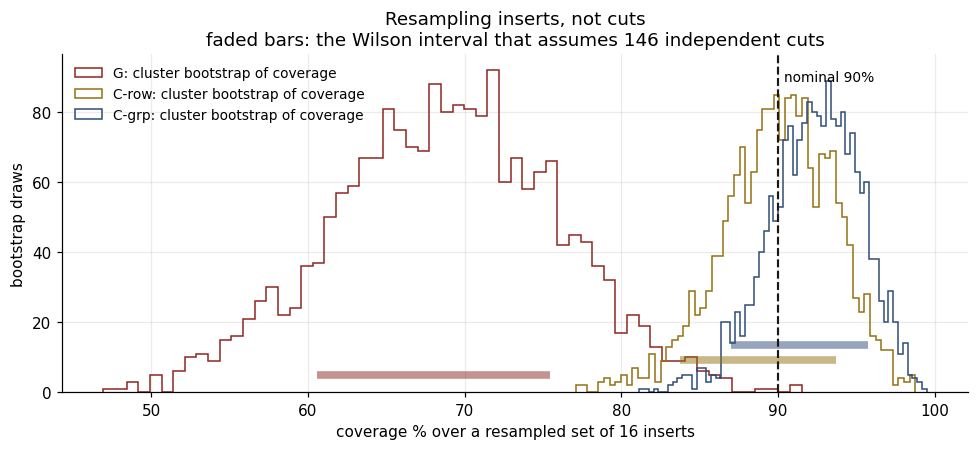

In [21]:
need_run("boot", "the cluster bootstrap cell just above")

series = [("G", MADDER), ("C-row", GOLD), ("C-grp", SLATE)]
n_rows = int(meta.groupby("seed").size().mean())

fig, ax = plt.subplots()
for c, colour in series:
    ax.hist(100 * boot[c], bins=60, histtype="step", lw=1.6, color=colour,
            label=f"{c}: cluster bootstrap of coverage")
top = ax.get_ylim()[1]
for i, (c, colour) in enumerate(series):
    pooled = float(meta.groupby("seed")[f"cov_{c}"].mean().mean())
    lo, hi = wilson(int(round(pooled * n_rows)), n_rows)
    ax.hlines(top * (0.05 + 0.045 * i), 100 * lo, 100 * hi, color=colour, lw=5, alpha=0.5)
ax.axvline(100 * (1 - ALPHA), color=INK, lw=1.4, ls="--")
ax.annotate("nominal 90%", (100 * (1 - ALPHA) + 0.4, top * 0.92), fontsize=9)
ax.set_xlabel("coverage % over a resampled set of 16 inserts")
ax.set_ylabel("bootstrap draws")
ax.set_title("Resampling inserts, not cuts\n"
             "faded bars: the Wilson interval that assumes 146 independent cuts")
ax.legend(frameon=False, fontsize=9, loc="upper left")
plt.tight_layout(); plt.show()

## 7. What honesty costs

An honest interval is wider, and a wider interval means pulling inserts earlier.
That is a real cost in tool life, and refusing to name it is how audits get
ignored. So name it, in the two counts a shop already tracks:

- **life thrown away** — cuts the insert still had when it was changed
- **run past the limit** — cuts taken after wear passed the change point

Four policies, all evaluated on inserts the model never saw, all counted in
physical cut numbers rather than in measured rows. The scoring functions are the
shipped ones, imported from `src/decision.py` and called here rather than run.

No currency appears anywhere below. The counts are ours; the rates are yours.

In [22]:
need_run("meta", "the calibrated.csv cell at the top of section 4")

def policy_table(frame: pd.DataFrame, limit: float) -> pd.DataFrame:
    """Life thrown away and cuts run past the limit, per 100 physical cuts."""
    out = []
    for seed, per_seed_frame in frame.groupby("seed"):
        tracks = [g.sort_values("cut_index").reset_index(drop=True)
                  for _, g in per_seed_frame.groupby("case")]
        total = sum(int(g["cut_index"].iloc[-1]) for g in tracks)
        plans = {
            "interval upper bound reaches limit": lambda g: g["pred"] + g["q_C-grp"] >= limit,
            "point prediction reaches limit": lambda g: g["pred"] >= limit,
            "interval lower bound reaches limit": lambda g: g["pred"] - g["q_C-grp"] >= limit,
        }
        for name, fires in plans.items():
            waste = late = 0
            for g in tracks:
                w, l = outcomes(g, first_cut_where(g, fires(g)), limit)
                waste, late = waste + w, late + l
            out.append({"policy": name, "waste": waste, "late": late, "cuts": total})
        for n_cuts in (12, 18):
            waste = late = 0
            for g in tracks:
                last = int(g["cut_index"].iloc[-1])
                w, l = outcomes(g, n_cuts if last >= n_cuts else None, limit)
                waste, late = waste + w, late + l
            out.append({"policy": f"fixed {n_cuts} cuts, regardless",
                        "waste": waste, "late": late, "cuts": total})
    agg = pd.DataFrame(out).groupby("policy", sort=False)[["waste", "late", "cuts"]].mean()
    return pd.DataFrame({"life thrown away / 100 cuts": 100 * agg["waste"] / agg["cuts"],
                         "run past limit / 100 cuts": 100 * agg["late"] / agg["cuts"]})


policies = policy_table(meta, WEAR_LIMIT)
print(f"wear limit {WEAR_LIMIT} mm, averaged over {meta['seed'].nunique()} calibration draws\n")
print(policies.round(2).to_string())

price = (policies.loc["interval upper bound reaches limit", "life thrown away / 100 cuts"]
         - policies.loc["interval lower bound reaches limit", "life thrown away / 100 cuts"])
saved = (policies.loc["interval lower bound reaches limit", "run past limit / 100 cuts"]
         - policies.loc["interval upper bound reaches limit", "run past limit / 100 cuts"])
print(f"\nThe price of near-certainty: driving over-limit cuts from "
      f"{policies.loc['interval lower bound reaches limit', 'run past limit / 100 cuts']:.1f} "
      f"to {policies.loc['interval upper bound reaches limit', 'run past limit / 100 cuts']:.1f} "
      f"per 100 cuts")
print(f"costs about {price:.0f} cuts of tool life per 100. That trade is the reader's to")
print(f"price, not ours; {saved:.1f} avoided over-limit cuts is what is being bought.")

wear limit 0.6 mm, averaged over 25 calibration draws

                                    life thrown away / 100 cuts  run past limit / 100 cuts
policy                                                                                    
interval upper bound reaches limit                        42.02                       0.39
point prediction reaches limit                             6.02                       3.01
interval lower bound reaches limit                         0.00                       6.02
fixed 12 cuts, regardless                                 12.65                       3.01
fixed 18 cuts, regardless                                  1.81                       4.82

The price of near-certainty: driving over-limit cuts from 6.0 to 0.4 per 100 cuts
costs about 42 cuts of tool life per 100. That trade is the reader's to
price, not ours; 5.6 avoided over-limit cuts is what is being bought.


In [23]:
need_run("policies", "the policy table cell in section 7")

if CURVE.exists():
    shipped_curve = pd.read_csv(CURVE)
    at_limit = shipped_curve[(shipped_curve["limit"] == WEAR_LIMIT)].set_index("policy")
    for here, there in [("interval upper bound reaches limit", "upper"),
                        ("interval lower bound reaches limit", "lower")]:
        delta = abs(policies.loc[here, "life thrown away / 100 cuts"]
                    - at_limit.loc[there, "waste_per_100"])
        print(f"{there:<6} life thrown away: notebook "
              f"{policies.loc[here, 'life thrown away / 100 cuts']:.4f} vs "
              f"decision_curve.csv {at_limit.loc[there, 'waste_per_100']:.4f}  "
              f"(diff {delta:.2e})")
        assert delta < 1e-9, f"the notebook's {there} policy is not the shipped one"
    print("\nmatches src/decision.py exactly.")
else:
    print(f"Missing {CURVE_REL}, so this optional cross-check is skipped.")
    print(f"  To enable it, from {ROOT}:")
    print(f"    {HOW_DECISION}")
    print("The table above is computed here regardless and does not depend on it.")

upper  life thrown away: notebook 42.0241 vs decision_curve.csv 42.0241  (diff 0.00e+00)
lower  life thrown away: notebook 0.0000 vs decision_curve.csv 0.0000  (diff 0.00e+00)

matches src/decision.py exactly.


## 8. What this does not support

**16 inserts.** That number bounds everything above.

- One machine, one tool geometry, one cutting speed. Two materials, two depths,
  two feeds.
- 10 of 16 inserts reached the 0.60 mm change point; 6 stopped short. The
  worn-tool regime therefore rests on fewer trajectories than the fresh-tool one,
  and the worn regime is where the decision lives.
- Every interval here is a **cluster bootstrap over inserts** rather than a
  row-level binomial interval, as section 6 showed. That is the correct
  construction and it is also why the intervals are wide. They are wide because
  16 is a small number. Reporting them narrower would be reporting a precision
  that does not exist.
- The dataset is from 1996. Tooling, coatings and controls have moved.

One of those deserves a check rather than a caveat. **0.60 mm is a convention,
not a property of the data**, so if the finding only holds at 0.60 it is an
artefact. Sweep the change point instead, using the shipped ablation.

In [24]:
need_run("res", "the calibrated.csv cell at the top of section 4")

ablation = ablation_sweep(res, "meta")
view = ablation[["wear_limit", "n_worn_per_seed", "cov_worn_G-cal", "cov_worn_C-grp",
                 "cov_worn_C-norm", "width_over_limit_C-grp"]]
view = view[view["wear_limit"].isin([0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90, 1.00])]
print(view.round(2).to_string(index=False))

crossing = ablation[ablation["width_over_limit_C-grp"] <= 1.0]["wear_limit"].min()
print(f"\nThe honest 90% interval is wider than the limit it polices at every change")
print(f"point below {crossing:.2f} mm.")
print("Worn-regime coverage falls as the change point rises: the finding is not an")
print("artefact of choosing 0.60, it is weakest there and strengthens above it.")

worn_at_60 = float(ablation.loc[ablation["wear_limit"] == WEAR_LIMIT, "cov_worn_C-grp"].iloc[0])
assert abs(worn_at_60 - 68.0) < 0.5, \
    f"article: 68.0% conformal coverage in the worn regime at 0.60 mm, got {worn_at_60:.1f}"

 wear_limit  n_worn_per_seed  cov_worn_G-cal  cov_worn_C-grp  cov_worn_C-norm  width_over_limit_C-grp
        0.3               70           75.77           87.66            91.94                    2.20
        0.4               52           73.15           85.08            90.46                    1.65
        0.5               29           65.66           77.66            85.24                    1.32
        0.6               20           55.00           68.00            78.60                    1.10
        0.7               12           35.67           53.00            72.67                    0.94
        0.8                8           22.00           40.00            63.00                    0.83
        0.9                5            8.80           28.80            62.40                    0.73
        1.0                4            0.00           16.00            53.00                    0.66

The honest 90% interval is wider than the limit it polices at every change
point 

The method transfers to any shop with measured outcomes. The specific numbers
describe this experiment.

### The check worth stealing

Split your data both ways. If the leaky split reports coverage close to nominal
while producing intervals materially sharper than the grouped split, the sharp
one is the wrong answer and the marginal check will never tell you. That is
section 5, it costs one loop, and it is the finding here that survives leaving
the machine shop.

### Where the code lives

| Step | Module | Run here as |
|---|---|---|
| Windowed features, clipped-channel flags | `src/features.py` | subprocess (expensive, once) |
| The 6 interval constructions | `src/calibrate.py` | subprocess (expensive, once) |
| Conformal quantile, model pipeline | `src/calibrate.py` | imported, cross-checked in §5 |
| Change-policy scoring | `src/decision.py` | imported, cross-checked in §7 |
| Wear-limit sensitivity | `src/ablation.py` | imported and called in §8 |
| Per-insert wear trajectories | `src/characterise.py` | rebuilt inline in §1 and §3 |
| Sensor anomaly check | `src/anomalies.py` | rebuilt inline in §2 |
| The row-split failure, as a script | `src/review_checks.py` | rebuilt inline in §5 and §6 |